In [29]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import and view dataset (Link:https://catalog.data.gov/dataset/vision-zero-crash-report-data)

df = pd.read_csv('C:\\Users\\aryap\\asds6302s26\\Austin_Crash_Report_Data_-_Crash_Level_Records.csv')
df.info()
df.describe()

C:\Users\aryap\AppData\Local\Temp\ipykernel_28232\3136777268.py:3: DtypeWarning: Columns (4,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\aryap\\asds6302s26\\Austin_Crash_Report_Data_-_Crash_Level_Records.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 47 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    228358 non-null  int64  
 1   Crash ID                              228355 non-null  float64
 2   crash_fatal_fl                        228358 non-null  bool   
 3   case_id                               225411 non-null  object 
 4   rpt_block_num                         197419 non-null  object 
 5   rpt_street_name                       228357 non-null  object 
 6   rpt_street_sfx                        155732 non-null  object 
 7   crash_speed_limit                     228358 non-null  int64  
 8   road_constr_zone_fl                   228356 non-null  object 
 9   latitude                              225329 non-null  float64
 10  longitude                             225329 non-null  float64
 11  

,ID,Crash ID,crash_speed_limit,latitude,longitude,crash_sev_id,sus_serious_injry_cnt,nonincap_injry_cnt,poss_injry_cnt,non_injry_cnt,...,motorcycle_serious_injury_count,other_death_count,other_serious_injury_count,micromobility_serious_injury_count,micromobility_death_count,Law enforcement fatality count,Reported street prefix,Estimated Maximum Comprehensive Cost,Estimated Total Comprehensive Cost,Location group
count,2.283580e+05,2.283550e+05,228358.000000,225329.000000,225329.000000,228358.000000,228358.000000,228358.000000,228358.000000,228358.000000,...,228358.000000,228358.0,228358.000000,228358.000000,228358.000000,228358.000000,0.0,2.283580e+05,2.283580e+05,208973.000000
mean,3.198317e+05,1.616475e+07,35.670509,30.299537,-97.738181,3.457308,0.034332,0.287378,0.352709,1.843719,...,0.004926,0.0,0.000044,0.000236,0.000039,0.003442,NaN,2.141706e+05,3.056280e+05,1.187201
std,3.826199e+05,2.788730e+06,22.544294,0.083108,0.052358,1.627714,0.211913,0.654602,0.753224,1.690187,...,0.072232,0.0,0.008370,0.016208,0.006278,0.062123,NaN,5.568484e+05,7.339058e+05,0.390074
min,2.000000e+00,1.115258e+07,-1.000000,30.098754,-97.927173,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,2.000000e+04,1.000000
25%,1.111752e+05,1.377692e+07,30.000000,30.233778,-97.769488,2.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,4.000000e+04,1.000000
50%,2.354695e+05,1.608885e+07,40.000000,30.285793,-97.736683,3.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,9.000000e+04,1.000000
75%,3.594558e+05,1.847572e+07,55.000000,30.364494,-97.702180,5.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+05,2.700000e+05,1.000000
max,1.803120e+06,2.134649e+07,85.000000,30.511625,-97.570148,5.000000,14.000000,57.000000,21.000000,75.000000,...,2.000000,0.0,3.000000,2.000000,1.000000,5.000000,NaN,3.500000e+06,4.224000e+07,2.000000


## Basic preprocessing and feature engineering (for MCC and Reg)

In [3]:
# basic preprocessing steps
# 1. standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.head()
# 2. check for missing values
df.isnull().sum()

id                                           0
crash_id                                     3
crash_fatal_fl                               0
case_id                                   2947
rpt_block_num                            30939
rpt_street_name                              1
rpt_street_sfx                           72626
crash_speed_limit                            0
road_constr_zone_fl                          2
latitude                                  3029
longitude                                 3029
crash_sev_id                                 0
sus_serious_injry_cnt                        0
nonincap_injry_cnt                           0
poss_injry_cnt                               0
non_injry_cnt                                0
unkn_injry_cnt                               0
tot_injry_cnt                                0
death_cnt                                    0
units_involved                               0
point                                     3029
motor_vehicle

crash id: MCAR; drop since only 3 missing
case_id: MNAR; add flag column then drop?
rpt_block_num: MAR; Add binary 'has_block_num' flag; drop raw col
rpt_street_name: 14k missing/high cardinality wo general pattern, will drop
rpt_street_sfx: Structural; Fill with 'NONE' (no suffix present)
road_constr_zone_fl: MCAR; Mode imputation (only 2 missing)
latitude: MAR/MNAR; KNN impute from address; add 'has_coords' flag
longitude: Same as latitude
point: drop, redundant
location_id: MAR/Struct; Add 'has_location_id' flag; drop raw col
location_group: MAR/Struct; Add 'has_location_group' flag or encode + flag
reported_street_prefix: Drop; 97% missing, no predictive value
address: MCAR; Mode imputation (only 7 missing)

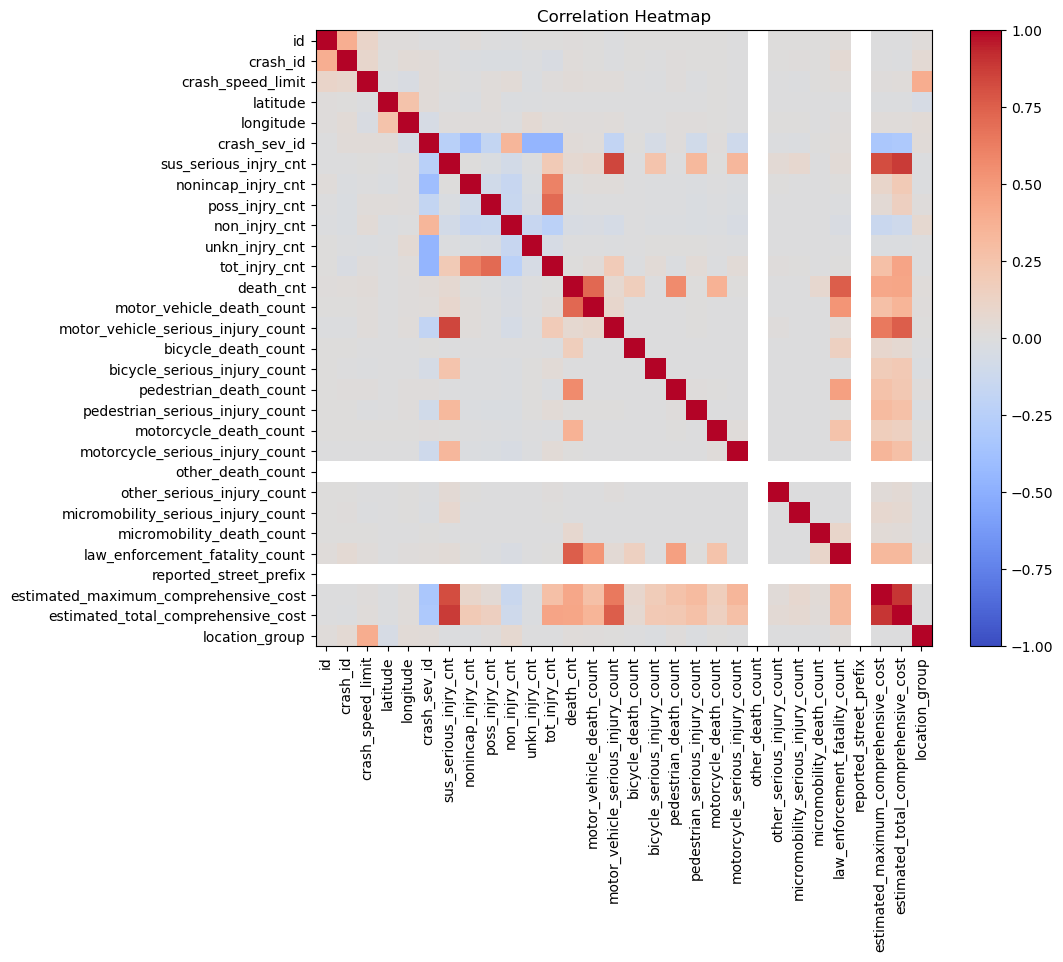

In [4]:
# creating correlation heatmap to identify highly correlated features
df_num = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = df_num.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

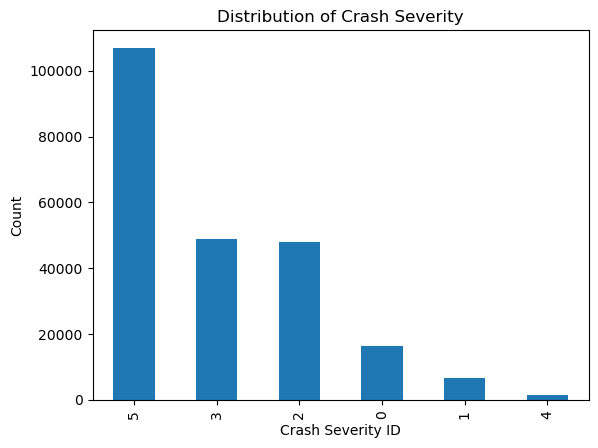

In [5]:
# 3. visulaize target class distribution and check for class imbalance
df['crash_sev_id'].value_counts()
df['crash_sev_id'].value_counts().plot(kind='bar')
plt.title('Distribution of Crash Severity')
plt.xlabel('Crash Severity ID')
plt.ylabel('Count')
plt.show()


0 = Unknown/Missing: Officer did not provide info or data was not recorded

1 = Fatal Injury(Inj) (K): injury resuled in death within 30 days of accident

2 = Suspected(Sus) serious Inj: incapacitating injury preventing continuation of daily activities (includes sever lacerations, unconsciousness, broken limbs, etc)

3 = Sus Minor Inj: Non-incapacitating injuries (bruises, abrasions, small cuts)

4 = Possible Inj: Injury is claimed/reported and indicated by behaviour (limping, moments of unconsciousness), but without visible wounds

5 = No Inj: No one involved in accident sustained an injury

*Based on Texas Peace Officer's Crash Report (CR-3) Code Sheet and Classification of Motor Vehicle Traffic Crashes in Texas manual. 

In [6]:
# 4. make copies of the original dataset for classification and regression tasks and begin cleaning
df_class = df.copy()
df_reg = df.copy()

In [7]:
# dropping high missing count
cols_drop = ['reported_street_prefix', 'rpt_street_sfx', 'rpt_block_num', 'rpt_street_name']

# columns not adding predictive value/redundant cols
cols_drop += ['id', 'crash_id', 'case_id', 'location_id', 'location_group', 'point', 'address', 'is_deleted', 'is_temporary_record']

# marking data leakage columns
cols_leak = ['death_cnt','tot_injry_cnt', 'sus_serious_injry_cnt', 'nonincap_injry_cnt', 'poss_injry_cnt', 'non_injry_cnt',
    'unkn_injry_cnt', 'motor_vehicle_death_count', 'motor_vehicle_serious_injury_count', 'bicycle_death_count', 
    'bicycle_serious_injury_count', 'pedestrian_death_count', 'pedestrian_serious_injury_count', 'motorcycle_death_count', 
    'motorcycle_serious_injury_count', 'other_death_count', 'other_serious_injury_count', 'micromobility_serious_injury_count',
    'micromobility_death_count', 'law_enforcement_fatality_count', 'estimated_total_comprehensive_cost', 'estimated_maximum_comprehensive_cost']

cols_drop += cols_leak

df_class.drop(columns=cols_drop, inplace=True)
df_reg.drop(columns=cols_drop, inplace=True)

df_class.isnull().sum()

crash_fatal_fl                   0
crash_speed_limit                0
road_constr_zone_fl              2
latitude                      3029
longitude                     3029
crash_sev_id                     0
units_involved                   0
onsys_fl                         0
private_dr_fl                    0
crash_timestamp_us/central       0
crash_timestamp                  0
collision_type                   0
dtype: int64

In [8]:
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_fatal_fl              228358 non-null  bool   
 1   crash_speed_limit           228358 non-null  int64  
 2   road_constr_zone_fl         228356 non-null  object 
 3   latitude                    225329 non-null  float64
 4   longitude                   225329 non-null  float64
 5   crash_sev_id                228358 non-null  int64  
 6   units_involved              228358 non-null  object 
 7   onsys_fl                    228358 non-null  bool   
 8   private_dr_fl               228358 non-null  bool   
 9   crash_timestamp_us/central  228358 non-null  object 
 10  crash_timestamp             228358 non-null  object 
 11  collision_type              228358 non-null  object 
dtypes: bool(3), float64(2), int64(2), object(5)
memory usage: 16.3+ MB


In [9]:
### address obj data type issue
# fixing unmarked missing values in crash_speed_limit column
df_class['crash_speed_limit'] = df_class['crash_speed_limit'].replace(-1, None)
df_class['crash_speed_limit'].isnull().sum()

np.int64(39481)

In [10]:
df_class['crash_speed_limit'].describe()

count     188877
unique        33
top           35
freq       35265
Name: crash_speed_limit, dtype: int64

In [11]:
# converting crash speed limit to numeric
df_class['crash_speed_limit'] = pd.to_numeric(df_class['crash_speed_limit'], errors='coerce')

# added missing flag just in case median imputation does not work well and we want to try treating missing as independent category and one hot encoding later
df_class['crash_speed_limit_missing'] = df_class['crash_speed_limit'].isnull().astype(int)

# decided median imputation is best for crash speed limit since it is a numeric column with outliers and skewed distribution (can also do treat missing as independent category and one hot encode but will try median imputation first)
df_class['crash_speed_limit'] = df_class['crash_speed_limit'].fillna(df_class['crash_speed_limit'].median())
df_class['crash_speed_limit'].isnull().sum()

np.int64(0)

In [12]:
df_class.isnull().sum()

crash_fatal_fl                   0
crash_speed_limit                0
road_constr_zone_fl              2
latitude                      3029
longitude                     3029
crash_sev_id                     0
units_involved                   0
onsys_fl                         0
private_dr_fl                    0
crash_timestamp_us/central       0
crash_timestamp                  0
collision_type                   0
crash_speed_limit_missing        0
dtype: int64

In [13]:
# converting crash fatal flag to numeric
df_class['crash_fatal_fl'] = df_class['crash_fatal_fl'].astype(int)
df_class['onsys_fl'] = df_class['onsys_fl'].astype(int)
df_class['private_dr_fl'] = df_class['private_dr_fl'].astype(int)
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_fatal_fl              228358 non-null  int64  
 1   crash_speed_limit           228358 non-null  float64
 2   road_constr_zone_fl         228356 non-null  object 
 3   latitude                    225329 non-null  float64
 4   longitude                   225329 non-null  float64
 5   crash_sev_id                228358 non-null  int64  
 6   units_involved              228358 non-null  object 
 7   onsys_fl                    228358 non-null  int64  
 8   private_dr_fl               228358 non-null  int64  
 9   crash_timestamp_us/central  228358 non-null  object 
 10  crash_timestamp             228358 non-null  object 
 11  collision_type              228358 non-null  object 
 12  crash_speed_limit_missing   228358 non-null  int64  
dtypes: float64(3),

In [14]:
# checking road construction zone flag column for missing values and unique values to determine how to handle
df_class[df_class['road_constr_zone_fl'].isna()]
df_class['road_constr_zone_fl'].unique()

array([False, True, nan], dtype=object)

In [15]:
df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].fillna(False)
df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].astype(bool)
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_fatal_fl              228358 non-null  int64  
 1   crash_speed_limit           228358 non-null  float64
 2   road_constr_zone_fl         228358 non-null  bool   
 3   latitude                    225329 non-null  float64
 4   longitude                   225329 non-null  float64
 5   crash_sev_id                228358 non-null  int64  
 6   units_involved              228358 non-null  object 
 7   onsys_fl                    228358 non-null  int64  
 8   private_dr_fl               228358 non-null  int64  
 9   crash_timestamp_us/central  228358 non-null  object 
 10  crash_timestamp             228358 non-null  object 
 11  collision_type              228358 non-null  object 
 12  crash_speed_limit_missing   228358 non-null  int64  
dtypes: bool(1), fl

C:\Users\aryap\AppData\Local\Temp\ipykernel_28232\1921735656.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].fillna(False)


In [16]:
df_class['units_involved'].value_counts()

units_involved
Passenger car                                                                   81407
Large passenger vehicle & Passenger car                                         76246
Large passenger vehicle                                                         34340
Motor vehicle – other & Passenger car                                            7499
Large passenger vehicle & Motor vehicle – other                                  3578
                                                                                ...  
Bicycle & Large passenger vehicle & Passenger car & Pedestrian                      1
Bicycle & Passenger car & Pedestrian                                                1
E-scooter & Motor vehicle – other & Passenger car                                   1
Micromobility device & Motor vehicle – other & Other/Unknown & Passenger car        1
Bicycle & Large passenger vehicle & Other/Unknown & Passenger car                   1
Name: count, Length: 80, dtype: int64

In [17]:
df_class['collision_type'].value_counts()

collision_type
ONE MOTOR VEHICLE - GOING STRAIGHT                             48738
SAME DIRECTION - ONE STRAIGHT-ONE STOPPED                      35407
SAME DIRECTION - BOTH GOING STRAIGHT-REAR END                  33913
ANGLE - BOTH GOING STRAIGHT                                    30441
OPPOSITE DIRECTION - ONE STRAIGHT-ONE LEFT TURN                21807
SAME DIRECTION - BOTH GOING STRAIGHT-SIDESWIPE                 16320
ANGLE - ONE STRAIGHT-ONE LEFT TURN                             10670
ANGLE - ONE STRAIGHT-ONE RIGHT TURN                             4757
ONE MOTOR VEHICLE - TURNING LEFT                                4720
SAME DIRECTION - ONE STRAIGHT-ONE LEFT TURN                     4382
ONE MOTOR VEHICLE - TURNING RIGHT                               3841
OPPOSITE DIRECTION - BOTH GOING STRAIGHT                        2925
SAME DIRECTION - ONE STRAIGHT-ONE RIGHT TURN                    2493
ONE MOTOR VEHICLE - OTHER                                       1129
ONE MOTOR VEHICLE -

High cardinality; apply grouping for collision types, extract number of units and presence of vehicle types for units involved?

In [18]:
def group_collision_types(ct):
    ct = str(ct)
    if 'REAR END' in ct:
        return 'rear_end'
    elif 'ANGLE' in ct:
        return 'angle'
    elif 'SIDESWIPE' in ct:
        return 'sideswipe'
    elif 'OPPOSITE DIRECTION' in ct:
        return 'head_on'
    elif 'ONE MOTOR VEHICLE' in ct:
        return 'single_vehicle'
    elif 'LEFT TURN' in ct or 'RIGHT TURN' in ct:
        return 'turning'
    elif 'BACKING' in ct or 'PARKED' in ct:
        return 'parking_related'
    else:
        return 'other'
df_class['collision_type_grouped'] = df_class['collision_type'].apply(group_collision_types)
df_class['collision_type_grouped'].value_counts()

collision_type_grouped
single_vehicle     59501
angle              47646
other              36383
rear_end           33913
head_on            26038
sideswipe          16320
turning             8544
parking_related       13
Name: count, dtype: int64

In [19]:
df_class['num_units'] = df_class['units_involved'].apply(lambda x: len(str(x).split('&')))
#indicator flags for presence of different vehicle types in units involved column
df_class['has_pedestrian'] = df_class['units_involved'].str.contains('Pedestrian', case=False, na=False).astype(int)
df_class['has_motorcycle'] = df_class['units_involved'].str.contains('Motorcycle', case=False, na=False).astype(int)
df_class['has_bicycle'] = df_class['units_involved'].str.contains('Bicycle', case=False, na=False).astype(int)
df_class['has_micromobility'] = df_class['units_involved'].str.contains('Micromobility', case=False, na=False).astype(int)
df_class['has_large_vehicle'] = df_class['units_involved'].str.contains('Large passenger vehicle', case=False, na=False).astype(int)
df_class['has_other'] = df_class['units_involved'].str.contains('other', case=False, na=False).astype(int)

df_class = df_class.drop(columns=['units_involved', 'collision_type'])
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_fatal_fl              228358 non-null  int64  
 1   crash_speed_limit           228358 non-null  float64
 2   road_constr_zone_fl         228358 non-null  bool   
 3   latitude                    225329 non-null  float64
 4   longitude                   225329 non-null  float64
 5   crash_sev_id                228358 non-null  int64  
 6   onsys_fl                    228358 non-null  int64  
 7   private_dr_fl               228358 non-null  int64  
 8   crash_timestamp_us/central  228358 non-null  object 
 9   crash_timestamp             228358 non-null  object 
 10  crash_speed_limit_missing   228358 non-null  int64  
 11  collision_type_grouped      228358 non-null  object 
 12  num_units                   228358 non-null  int64  
 13  has_pedestrian

In [20]:
df_class.head()

,crash_fatal_fl,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,crash_timestamp_us/central,crash_timestamp,crash_speed_limit_missing,collision_type_grouped,num_units,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other
0,0,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,01/15/2014 01:06:00 PM,0,rear_end,1,0,0,0,0,0,0
1,0,30.0,False,NaN,NaN,5,0,0,01/10/2014 12:18:00 PM,01/10/2014 06:18:00 PM,0,single_vehicle,1,0,0,0,0,0,0
2,0,45.0,False,NaN,NaN,5,1,0,01/12/2014 06:58:00 PM,01/13/2014 12:58:00 AM,1,other,2,0,0,0,0,1,0
3,0,65.0,False,NaN,NaN,5,1,0,01/22/2014 07:08:00 PM,01/23/2014 01:08:00 AM,0,single_vehicle,1,0,1,0,0,0,0
4,0,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,01/15/2014 01:06:00 PM,0,other,2,0,0,0,0,1,0


In [21]:
# drop crash fatal flag, keep only one timestamp for date and time of crash (not using utc version)
df_class = df_class.drop(columns=['crash_fatal_fl', 'crash_timestamp'])
df_class['crash_timestamp'] = pd.to_datetime(df_class['crash_timestamp_us/central'], errors='coerce')
df_class['hour'] = df_class['crash_timestamp'].dt.hour
df_class['day_of_week'] = df_class['crash_timestamp'].dt.dayofweek
df_class


,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,crash_timestamp_us/central,crash_speed_limit_missing,collision_type_grouped,num_units,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other,crash_timestamp,hour,day_of_week
0,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,0,rear_end,1,0,0,0,0,0,0,2014-01-15 07:06:00,7,2
1,30.0,False,NaN,NaN,5,0,0,01/10/2014 12:18:00 PM,0,single_vehicle,1,0,0,0,0,0,0,2014-01-10 12:18:00,12,4
2,45.0,False,NaN,NaN,5,1,0,01/12/2014 06:58:00 PM,1,other,2,0,0,0,0,1,0,2014-01-12 18:58:00,18,6
3,65.0,False,NaN,NaN,5,1,0,01/22/2014 07:08:00 PM,0,single_vehicle,1,0,1,0,0,0,0,2014-01-22 19:08:00,19,2
4,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,0,other,2,0,0,0,0,1,0,2014-01-15 07:06:00,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228353,45.0,False,30.279487,-97.645713,2,0,0,12/19/2025 04:43:00 PM,0,other,2,0,0,0,0,1,0,2025-12-19 16:43:00,16,4
228354,40.0,False,30.254468,-97.762472,5,1,0,01/23/2026 03:35:00 PM,0,angle,1,0,0,0,0,0,0,2026-01-23 15:35:00,15,4
228355,45.0,False,30.448384,-97.661850,2,0,0,02/15/2026 12:14:00 AM,1,head_on,1,0,0,0,0,0,0,2026-02-15 00:14:00,0,6
228356,65.0,False,30.175795,-97.890291,5,1,0,03/03/2026 12:01:00 AM,0,single_vehicle,1,0,0,0,0,0,0,2026-03-03 00:01:00,0,1


In [ ]:
# creating time buckets for rush hour vs non rush hours
def time_of_day(hour):
    if 7 <= hour < 10:
        return 'morning_rush'
    elif 10 <= hour < 16:
        return 'midday'
    elif 16 <= hour < 19:
        return 'evening_rush'
    else:
        return 'non_rush'
df_class['time_bucket'] = df_class['hour'].apply(time_of_day)

df_class = df_class.drop(columns=['crash_timestamp_us/central', 'crash_timestamp'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          228358 non-null  float64
 1   road_constr_zone_fl        228358 non-null  bool   
 2   latitude                   225329 non-null  float64
 3   longitude                  225329 non-null  float64
 4   crash_sev_id               228358 non-null  int64  
 5   onsys_fl                   228358 non-null  int64  
 6   private_dr_fl              228358 non-null  int64  
 7   crash_speed_limit_missing  228358 non-null  int64  
 8   collision_type_grouped     228358 non-null  object 
 9   num_units                  228358 non-null  int64  
 10  has_pedestrian             228358 non-null  int64  
 11  has_motorcycle             228358 non-null  int64  
 12  has_bicycle                228358 non-null  int64  
 13  has_micromobility          22

In [23]:
# lat and long imputation and missing indicator
df_class['lat_long_missing'] = df_class['latitude'].isnull().astype(int)

df_class['latitude'] = df_class['latitude'].fillna(df_class['latitude'].median())
df_class['longitude'] = df_class['longitude'].fillna(df_class['longitude'].median())
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          228358 non-null  float64
 1   road_constr_zone_fl        228358 non-null  bool   
 2   latitude                   228358 non-null  float64
 3   longitude                  228358 non-null  float64
 4   crash_sev_id               228358 non-null  int64  
 5   onsys_fl                   228358 non-null  int64  
 6   private_dr_fl              228358 non-null  int64  
 7   crash_speed_limit_missing  228358 non-null  int64  
 8   collision_type_grouped     228358 non-null  object 
 9   num_units                  228358 non-null  int64  
 10  has_pedestrian             228358 non-null  int64  
 11  has_motorcycle             228358 non-null  int64  
 12  has_bicycle                228358 non-null  int64  
 13  has_micromobility          22

In [25]:
df_class.head()

,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,crash_speed_limit_missing,collision_type_grouped,num_units,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other,hour,day_of_week,time_bucket,lat_long_missing
0,65.0,False,30.285793,-97.736683,5,1,0,0,rear_end,1,0,0,0,0,0,0,7,2,morning_rush,1
1,30.0,False,30.285793,-97.736683,5,0,0,0,single_vehicle,1,0,0,0,0,0,0,12,4,midday,1
2,45.0,False,30.285793,-97.736683,5,1,0,1,other,2,0,0,0,0,1,0,18,6,evening_rush,1
3,65.0,False,30.285793,-97.736683,5,1,0,0,single_vehicle,1,0,1,0,0,0,0,19,2,non_rush,1
4,65.0,False,30.285793,-97.736683,5,1,0,0,other,2,0,0,0,0,1,0,7,2,morning_rush,1


## EDA of df_class for MCC

In [ ]:
### Target Distribution
df_class['crash_sev_id'].value_counts().sort_index()
df_class['crash_sev_id'].value_counts(normalize=True) * 100

crash_sev_id
5    46.860631
3    21.391850
2    20.992477
0     7.228562
1     2.946251
4     0.580229
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Crash Speed Limit by Crash Severity')

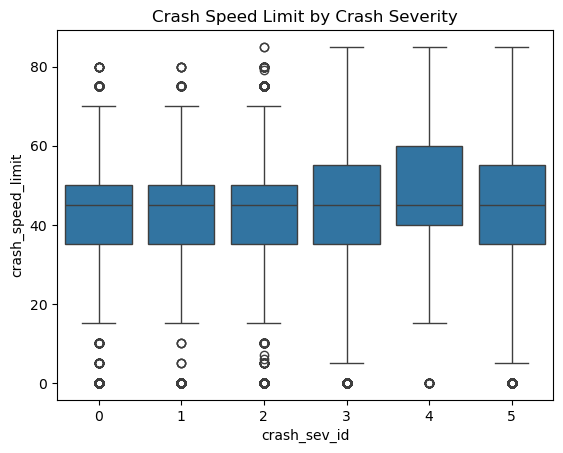

In [ ]:
### Features v target relationships
## numerical vs severity
sns.boxplot(x='crash_sev_id', y='crash_speed_limit', data=df_class)
plt.title('Crash Speed Limit by Crash Severity')

# need to do for num units and hour?

Text(0.5, 1.0, 'Collision Type by Crash Severity')

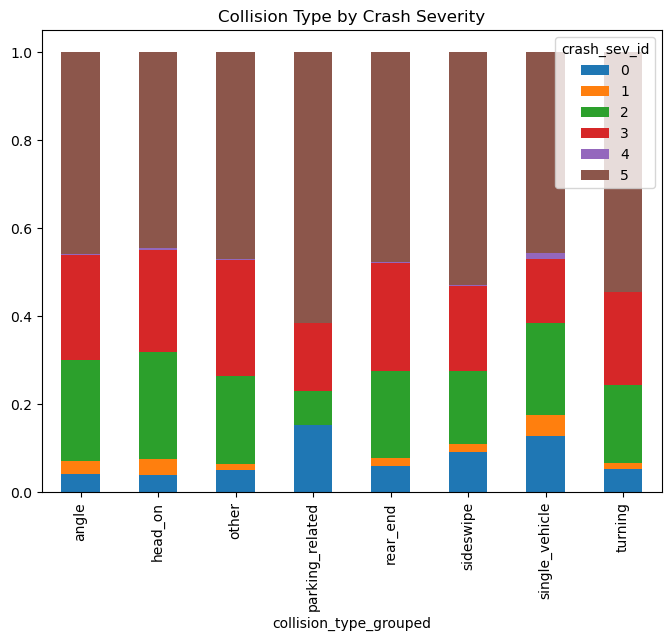

In [31]:
## categorical v target
ct = pd.crosstab(df_class['collision_type_grouped'], df_class['crash_sev_id'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title('Collision Type by Crash Severity')

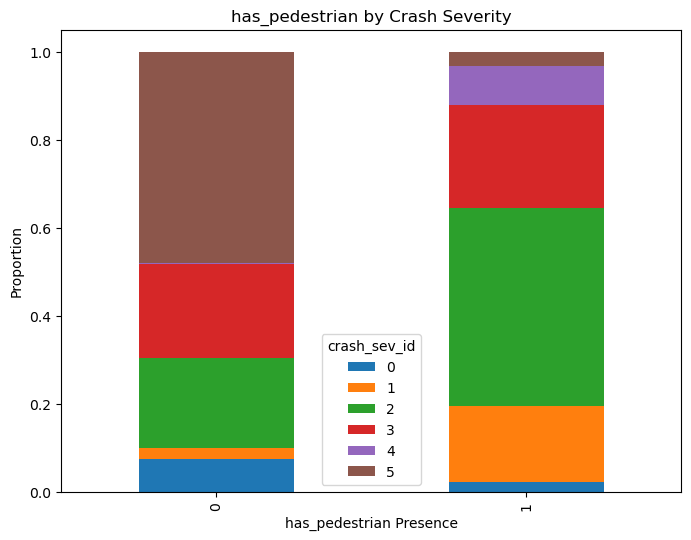

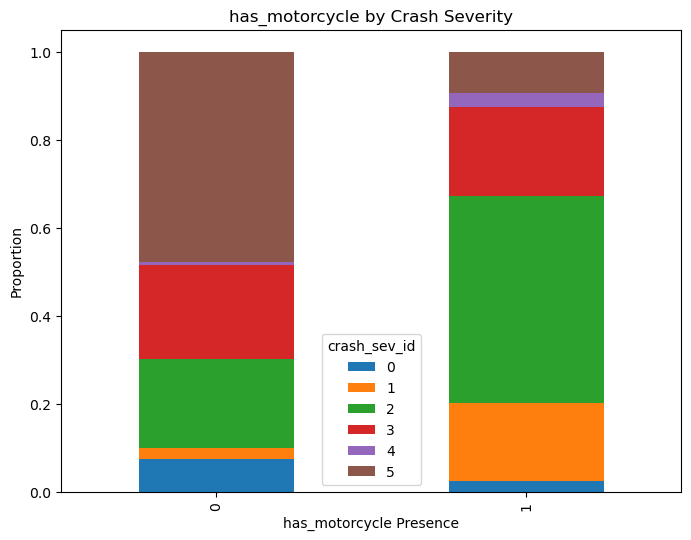

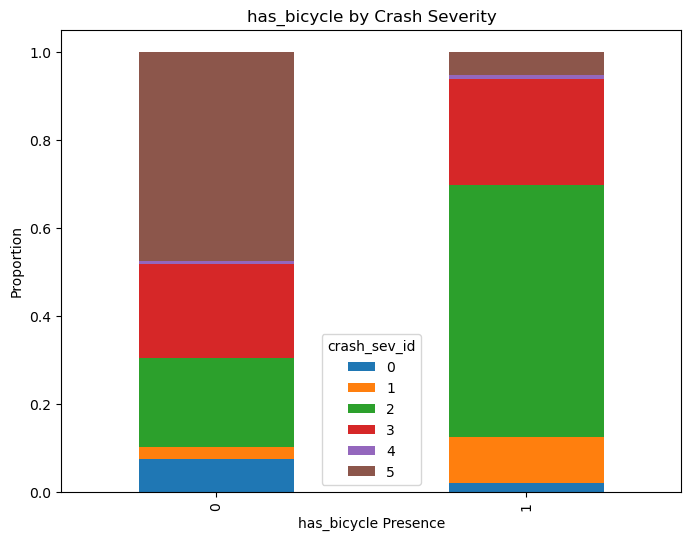

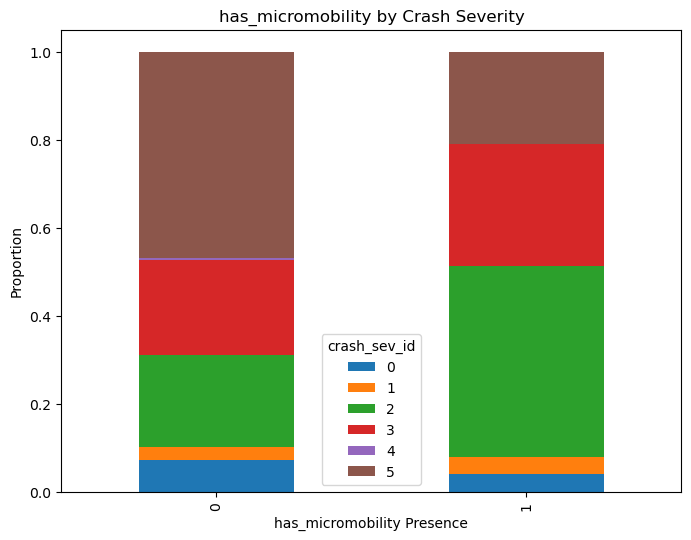

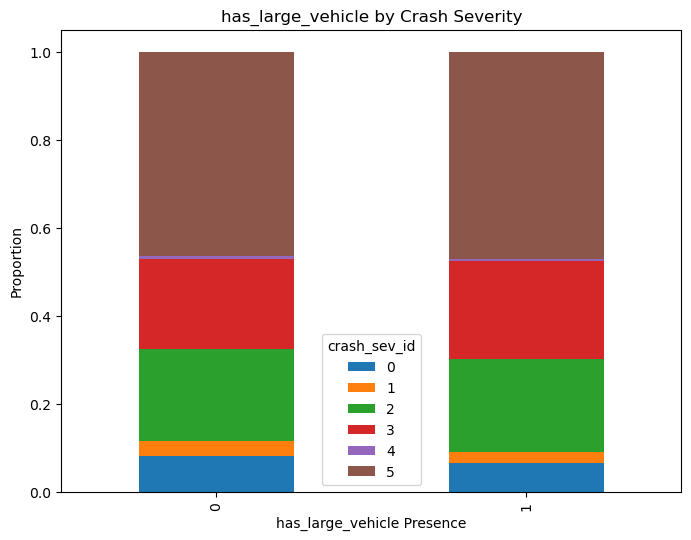

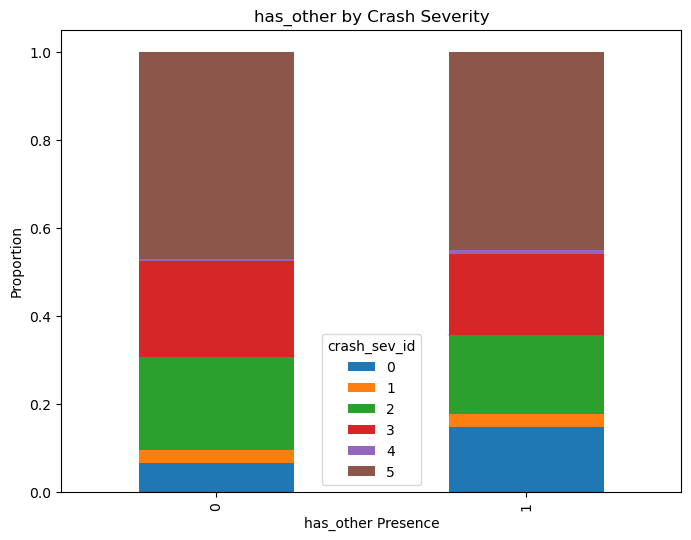

In [32]:
## binary features v target
feat = ['has_pedestrian', 'has_motorcycle', 'has_bicycle', 'has_micromobility', 'has_large_vehicle', 'has_other']
for f in feat:
    ct = pd.crosstab(df_class[f], df_class['crash_sev_id'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(8,6))
    plt.title(f'{f} by Crash Severity')
    plt.xlabel(f'{f} Presence')
    plt.ylabel('Proportion')
    plt.show()

Text(0.5, 1.0, 'Crash Severity by Hour')

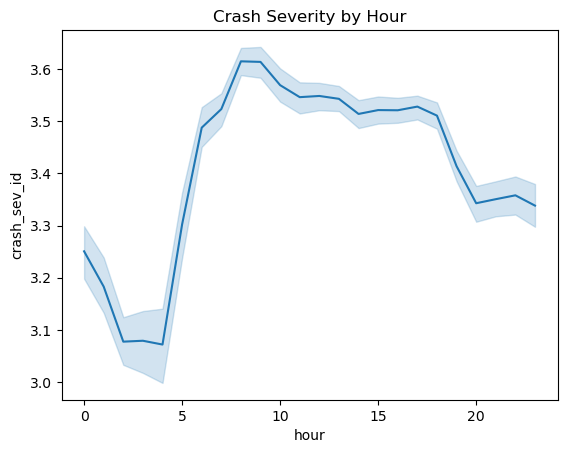

In [33]:
### time based
## severity by hour
sns.lineplot(x='hour', y='crash_sev_id', data=df_class)
plt.title('Crash Severity by Hour')


<Axes: xlabel='time_bucket'>

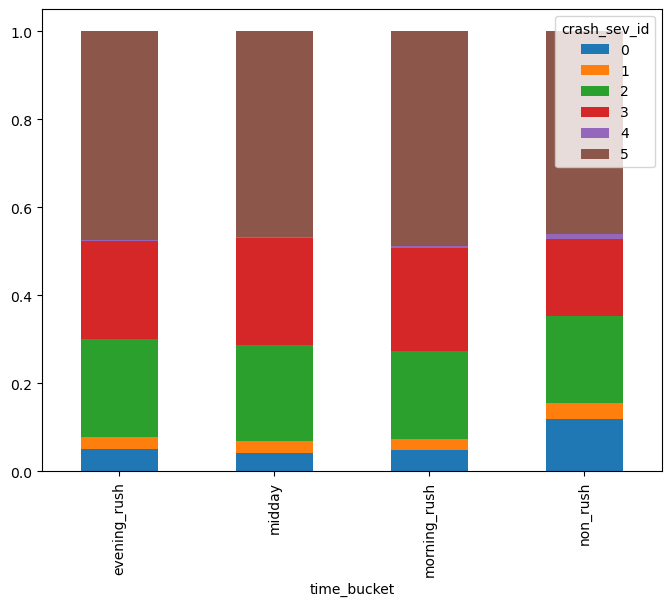

In [35]:
## time bucket v severity
pd.crosstab(df_class['time_bucket'], df_class['crash_sev_id'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,6))

<Axes: xlabel='day_of_week'>

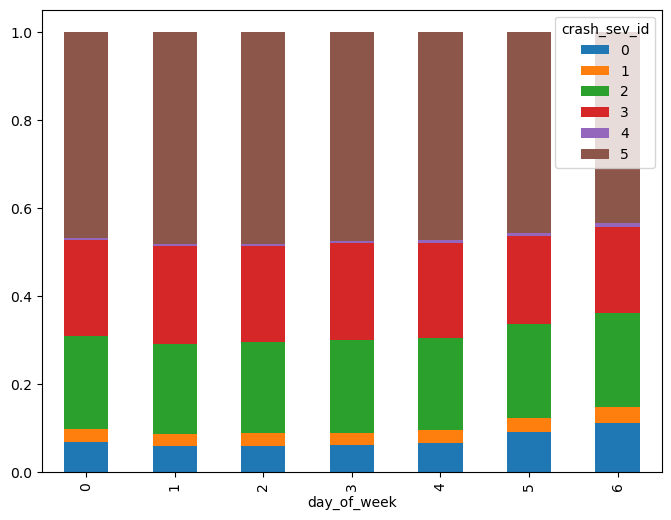

In [36]:
## day of week v severity
pd.crosstab(df_class['day_of_week'], df_class['crash_sev_id'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,6))

In [38]:
pd.crosstab(df_class['day_of_week'], df_class['crash_sev_id'], normalize='index')

crash_sev_id,0,1,2,3,4,5
day_of_week,,,,,,
0,0.068003,0.029945,0.209352,0.219127,0.004757,0.468817
1,0.057891,0.026801,0.205312,0.223017,0.005628,0.481352
2,0.059433,0.027746,0.207572,0.218572,0.005072,0.481605
3,0.061578,0.026676,0.211176,0.220048,0.004495,0.476027
4,0.066287,0.028738,0.208336,0.217544,0.004922,0.474173
5,0.089861,0.031528,0.213304,0.200086,0.007422,0.457799
6,0.110038,0.036112,0.215480,0.195614,0.008938,0.433818


Text(0.5, 1.0, 'Crash Severity by Location')

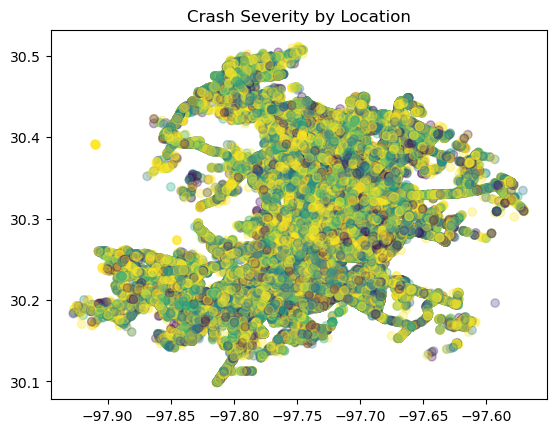

In [37]:
### Geospatial features v severity
## scatterplot
plt.scatter(df_class['longitude'], df_class['latitude'], c=df_class['crash_sev_id'], cmap='viridis', alpha=0.3)
plt.title('Crash Severity by Location')

In [ ]:
# vif for regression task

In [ ]:
# 4. make copy and drop rows with class 0
df_class = df.copy()
df_reg = df.copy()
df_class = df_class[df_class['crash_sev_id'] != 0]